<a href="https://colab.research.google.com/github/evanparisya/PCVK25_3F_09/blob/main/Week3_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **D1. Operasi Citra Sederhana**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Mengubah tingkat kecerahan citra 
---------------------------------
Masukkan nilai kecerahan: 50


/tmp/ipython-input-1807727210.py:24: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y, x, c] = np.clip(original[y, x, c] + brightness, 0, 255)


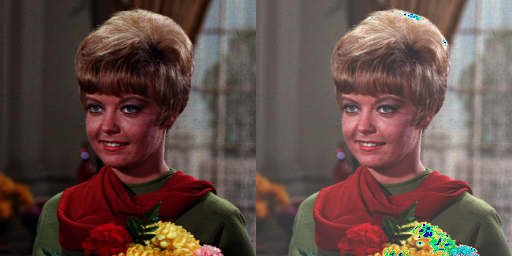

In [ ]:
# 2. Akses folder images pada Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 3. Melakukan transformasi linier brightness
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np

print(' Mengubah tingkat kecerahan citra ')
print('---------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/female.tiff')
brightness_image = np.zeros(original.shape, original.dtype)

#makes per piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y, x, c] = np.clip(original[y, x, c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat([original, brightness_image])
cv2_imshow(final_frame)

# TUGAS PRAKTIKUM D1

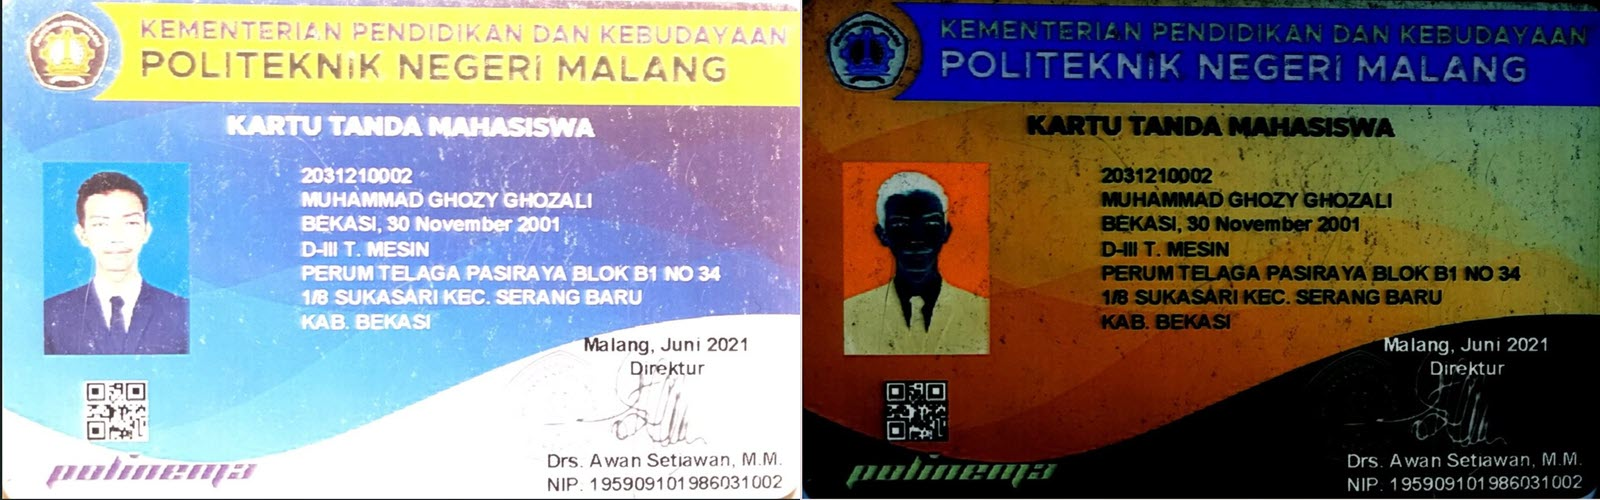

In [ ]:
# 1. Implementasikan inverse citra
original = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/KTM lama.jpg')
inverse_image = np.zeros(original.shape, original.dtype)

#makes per piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            inverse_image[y, x, c] = 255 - original[y, x, c]

final_frame = cv.hconcat([original, inverse_image])
cv2_imshow(final_frame)

 Mengubah tingkat kontras dan tingkat kecerahan citra 
---------------------------------
Masukkan nilai kecerahan [-255 - 255]: 50
Masukkan nilai kontras [1.0 - 3.0]: 2


/tmp/ipython-input-3984926573.py:19: RuntimeWarning: overflow encountered in scalar multiply
  contrast_image[y, x, c] = np.clip(contrast * original[y, x, c], 0, 255)
/tmp/ipython-input-3984926573.py:18: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y, x, c] = np.clip(original[y, x, c] + brightness, 0, 255)


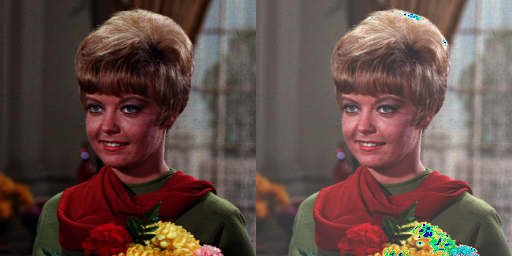

In [ ]:
# 2. Implementasikan transformasi contrast
print(' Mengubah tingkat kontras dan tingkat kecerahan citra ')
print('---------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan [-255 - 255]: '))
    contrast = int(input('Masukkan nilai kontras [1.0 - 3.0]: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/female.tiff')
brightness_image = np.zeros(original.shape, original.dtype)
contrast_image = np.zeros(original.shape, original.dtype)

#makes per piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y, x, c] = np.clip(original[y, x, c] + brightness, 0, 255)
            contrast_image[y, x, c] = np.clip(contrast * original[y, x, c], 0, 255)

final_frame = cv.hconcat([original, brightness_image])
cv2_imshow(final_frame)

 Mengubah tingkat kecerahan citra dengan Transformasi Log
---------------------------------
Masukkan nilai kecerahan: 50


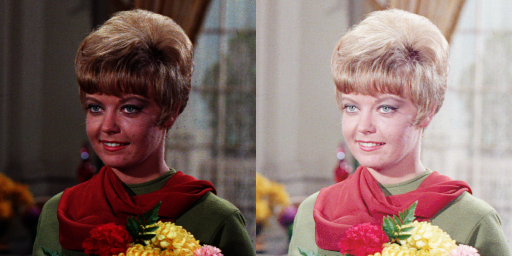

In [ ]:
# 3. Implementasikan transformasi logarithmic brightness
print(' Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('---------------------------------')
try:
    brightness = float(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/female.tiff')
log_image = np.zeros(original.shape, dtype=np.uint8)

# Konstanta log
c = 255 / np.log(1 + np.max(original))

#makes per piksel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c_channel in range(original.shape[2]):
            r = original[y, x, c_channel]
            s = c * np.log(1 + r)
            log_image[y, x, c_channel] = np.clip(s, 0, 255)

final_frame = cv.hconcat([original, log_image])
cv2_imshow(final_frame)

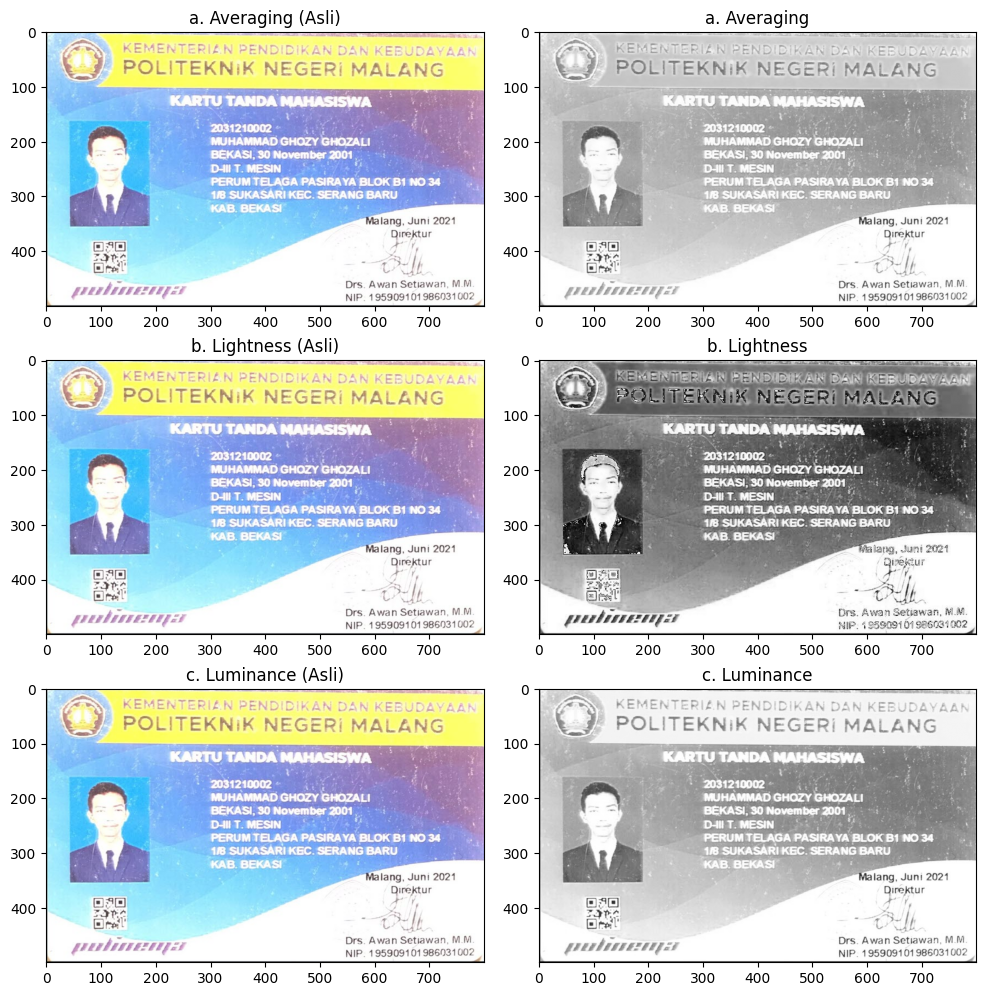

In [ ]:
# 4. Implementasikan transformasi grayscale
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/KTM lama.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

B, G, R = cv.split(original)

methods = {
    "a. Averaging": ((R.astype(np.float32) + G.astype(np.float32) + B.astype(np.float32)) / 3).astype(np.uint8),
    "b. Lightness": ((np.maximum(np.maximum(R, G), B) + np.minimum(np.minimum(R, G), B)) / 2).astype(np.uint8),
    "c. Luminance": (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)
}

plt.figure(figsize=(10,10))

for i, (name, gray) in enumerate(methods.items(), 1):
    # gambar asli
    plt.subplot(len(methods), 2, 2*i-1)
    plt.imshow(original_rgb)
    plt.title(f"{name} (Asli)")
    plt.axis("on")

    # gambar grayscale
    plt.subplot(len(methods), 2, 2*i)
    plt.imshow(gray, cmap="gray")
    plt.title(name)
    plt.axis("on")

plt.tight_layout()
plt.show()


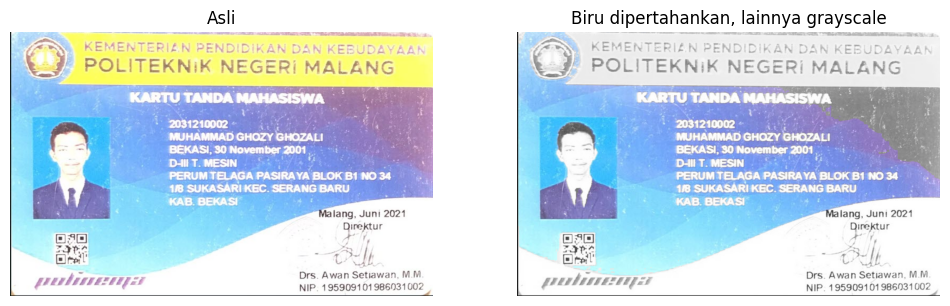

In [ ]:
# 5. Tampilkanlah warna tertentu pada citra
original = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/KTM lama.jpg')
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

lower_blue = np.array([90, 50, 50])
upper_blue = np.array([130, 255, 255])

mask = cv.inRange(hsv, lower_blue, upper_blue)

color_part = cv.bitwise_and(original_rgb, original_rgb, mask=mask)

gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
gray_rgb = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

final = np.where(mask[:, :, None].astype(bool), original_rgb, gray_rgb)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1), plt.imshow(original_rgb), plt.title("Asli")
plt.axis("off")
plt.subplot(1,2,2), plt.imshow(final), plt.title("Biru dipertahankan, lainnya grayscale")
plt.axis("off")
plt.show()

# **D2. Operasi Aritmatika dan Logika**

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 Gamma Correction 
------------------
Masukkan nilai gamma: 3


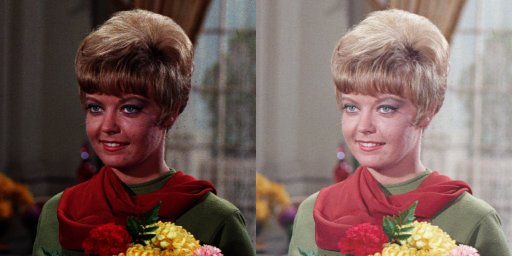

In [3]:
# 1. Buat Gamma Correction
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np

print(' Gamma Correction ')
print('------------------')
try:
    gamma = float(input('Masukkan nilai gamma: '))
except ValueError:
    print('Error, not a number')
    gamma = 1.0

# Baca citra
original = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/female.tiff')

# Lookup table untuk gamma correction
inv_gamma = 1.0 / gamma
table = np.array([((i / 255.0) ** inv_gamma) * 255
                  for i in np.arange(256)]).astype("uint8")

gamma_image = cv.LUT(original, table)

# Gabungkan citra asli dan hasil
final_frame = cv.hconcat([original, gamma_image])
cv2_imshow(final_frame)


 Simulasi Image Depth (Bit Quantization) 
-----------------------------------------


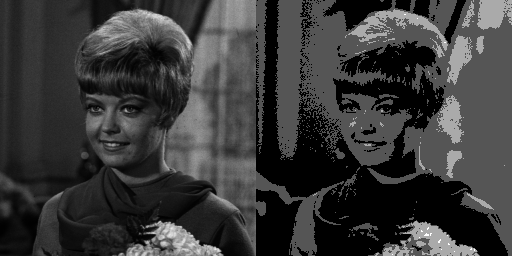

In [5]:
# 2. Buat Simulasi Image Depth
print(' Simulasi Image Depth (Bit Quantization) ')
print('-----------------------------------------')

bit_depth = 2
level = 255.0 / (2**bit_depth - 1)

original = cv.imread('/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/female.tiff', cv.IMREAD_GRAYSCALE)


bit_img = np.round(original / level) * level
bit_img = bit_img.astype(np.uint8)

final_frame = cv.hconcat([original, bit_img])
cv2_imshow(final_frame)


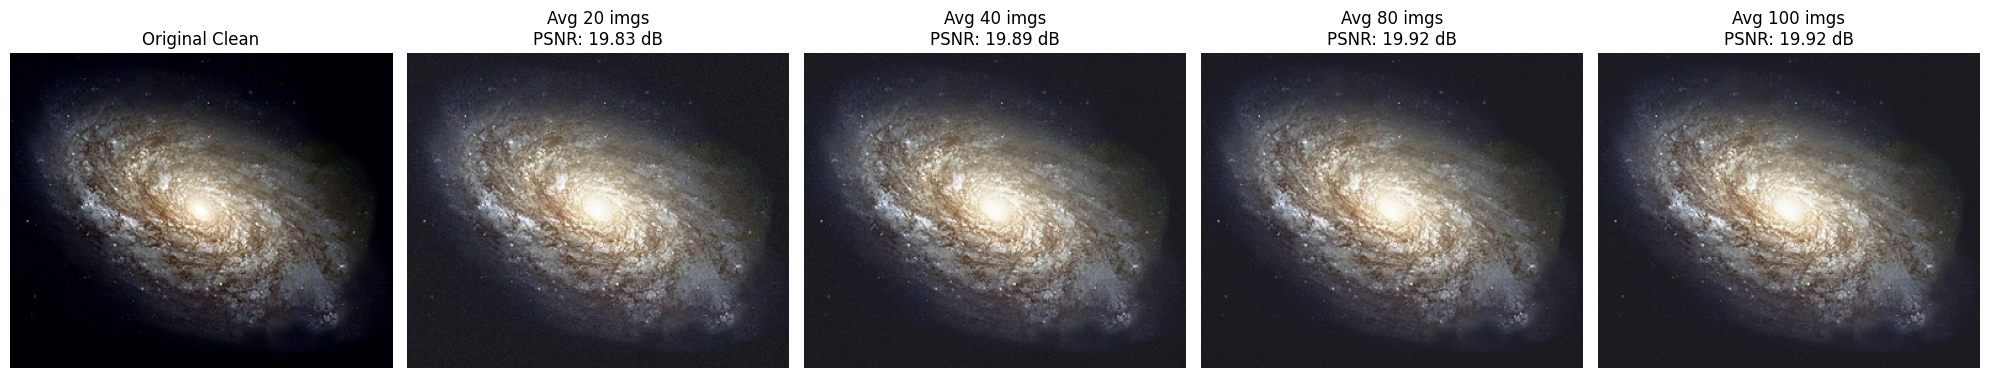

In [7]:
# 3. Buat modul Average Denoising
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

# Path citra
path_clean = "/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/galaxy.jpg"
path_noises = "/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/noises/*.jpg"

# Baca semua gambar noisy
noisy_image_paths = glob.glob(path_noises)
num_total = len(noisy_image_paths)

# Fungsi hitung PSNR
def calculate_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse))

# Baca gambar asli (clean)
clean_image_bgr = cv2.imread(path_clean)
clean_image_rgb = cv2.cvtColor(clean_image_bgr, cv2.COLOR_BGR2RGB)

# List jumlah citra yang akan diuji
samples = [20, 40, 80, num_total]
results = []

for n in samples:
    # Ambil n citra noisy pertama
    selected_paths = noisy_image_paths[:n]

    # Ambil dimensi
    sample_img = cv2.imread(selected_paths[0])
    h, w, c = sample_img.shape
    sum_image = np.zeros((h, w, c), np.float64)

    # Loop dan jumlahkan
    for path in selected_paths:
        img = cv2.imread(path)
        sum_image += img.astype(np.float64)

    # Rata-rata
    avg_image = sum_image / n
    denoised_bgr = avg_image.astype(np.uint8)
    denoised_rgb = cv2.cvtColor(denoised_bgr, cv2.COLOR_BGR2RGB)

    # Hitung PSNR terhadap citra asli
    psnr_value = calculate_psnr(clean_image_bgr, denoised_bgr)
    results.append((n, denoised_rgb, psnr_value))

# === Tampilkan hasil ===
fig, axes = plt.subplots(1, len(results)+1, figsize=(20, 6))

# Gambar asli
axes[0].imshow(clean_image_rgb)
axes[0].set_title("Original Clean")
axes[0].axis("off")

# Gambar hasil denoising
for i, (n, img_rgb, psnr) in enumerate(results):
    axes[i+1].imshow(img_rgb)
    axes[i+1].set_title(f"Avg {n} imgs\nPSNR: {psnr:.2f} dB")
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()

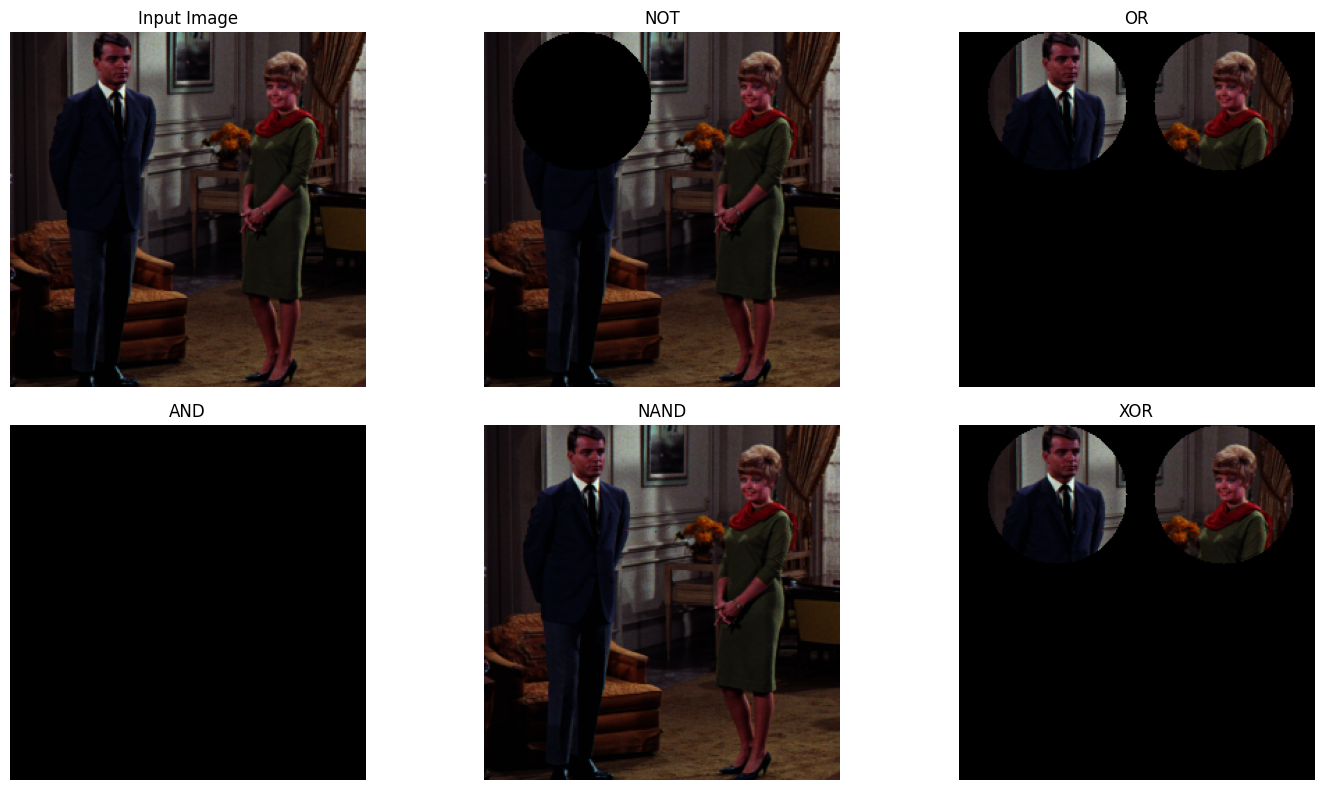

In [9]:
# 4. Buat image masking
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Path ke file gambar
image_path = "/content/drive/MyDrive/Colab Notebooks/PCVK25_3F_09/couple.tiff"

# Baca gambar asli
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Dapatkan dimensi gambar
height, width, _ = img_bgr.shape

# Buat masker lingkaran pria
mask1 = np.zeros((height, width), dtype=np.uint8)
cv2.circle(mask1, (70, 50), 50, 255, -1)

# Buat masker lingkaran wanita
mask2 = np.zeros((height, width), dtype=np.uint8)
cv2.circle(mask2, (190, 50), 50, 255, -1)

# --- Operasi Logika ---
mask_not  = cv2.bitwise_not(mask1)               # NOT
mask_or   = cv2.bitwise_or(mask1, mask2)         # OR
mask_and  = cv2.bitwise_and(mask1, mask2)        # AND
mask_nand = cv2.bitwise_not(mask_and)            # NAND
mask_xor  = cv2.bitwise_xor(mask1, mask2)        # XOR

# Terapkan ke gambar asli
res_not  = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_not)
res_or   = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_or)
res_and  = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_and)
res_nand = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_nand)
res_xor  = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_xor)

# Konversi ke RGB untuk matplotlib
results = {
    "NOT": cv2.cvtColor(res_not, cv2.COLOR_BGR2RGB),
    "OR": cv2.cvtColor(res_or, cv2.COLOR_BGR2RGB),
    "AND": cv2.cvtColor(res_and, cv2.COLOR_BGR2RGB),
    "NAND": cv2.cvtColor(res_nand, cv2.COLOR_BGR2RGB),
    "XOR": cv2.cvtColor(res_xor, cv2.COLOR_BGR2RGB),
}

# --- Tampilkan Hasil ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Input
axes[0,0].imshow(img_rgb)
axes[0,0].set_title("Input Image")
axes[0,0].axis("off")

# Hasil operasi
for ax, (title, output) in zip(axes.flat[1:], results.items()):
    ax.imshow(output)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()